# Extended Structural Features Extraction

Extracts document-level structural signals from the 323 modeling companies' 10-K section JSON files that are not captured by FinBERT sentiment or keyword frequencies.

**Features extracted per section (business, risk_factors, mda):**
- Word count
- Sentence count (uncapped — unlike FinBERT's capped version)
- Average sentence length in characters
- Flesch-Kincaid readability grade level
- Quantitative density (numeric mentions per 1,000 words)

**Cross-section aggregate features:**
- Section-length bucket flags (above median word count per section type)
- Quantitative MD&A flag (MD&A quant density above dataset median)
- Mean FK grade across all three sections
- Total word count across all sections

**Output:** `data/structured_features/extended_structural_features.csv`

## Step 1 — Imports and Configuration

In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

SECTIONS_DIR = "../data/extracted_sections"
QUALITY_CSV  = "../data/structured_features/extraction_quality.csv"
OUTPUT_CSV   = "../data/structured_features/extended_structural_features.csv"

SECTIONS = ["business", "risk_factors", "mda"]

# Sentence boundary: period/!/? followed by whitespace then capital letter
_SENT_RE = re.compile(r'(?<=[.!?])\s+(?=[A-Z])')
# Numeric mentions: integers and decimals
_NUM_RE  = re.compile(r'\b\d+(?:[,.]\d+)*\b')

print("Imports OK")

Imports OK


## Step 2 — Load Modeling Companies (323 after quality filter)

In [2]:
quality = pd.read_csv(QUALITY_CSV)
modeling_tickers = set(quality.loc[quality["bad_extraction"] != 2, "ticker"])
print(f"Modeling companies: {len(modeling_tickers)}")

available_files = {f.replace(".json", "") for f in os.listdir(SECTIONS_DIR) if f.endswith(".json")}
tickers = sorted(modeling_tickers & available_files)
print(f"JSON files found for modeling companies: {len(tickers)}")

Modeling companies: 323
JSON files found for modeling companies: 323


## Step 3 — Feature Extraction Functions

In [3]:
def sentence_count(text):
    """Total sentences in section (uncapped, unlike FinBERT's ESG-filtered version)."""
    return len([s for s in _SENT_RE.split(text) if s.strip()])

def word_count(text):
    return len(text.split())

def avg_sentence_length(text):
    """Mean sentence length in characters."""
    sentences = [s.strip() for s in _SENT_RE.split(text) if s.strip()]
    if not sentences:
        return 0.0
    return float(np.mean([len(s) for s in sentences]))

def fk_grade(text):
    """Flesch-Kincaid grade level. Higher = more complex prose."""
    try:
        return textstat.flesch_kincaid_grade(text[:50_000])
    except Exception:
        return np.nan

def quant_density(text):
    """Numeric mentions per 1,000 words."""
    words = len(text.split())
    if words == 0:
        return 0.0
    return len(_NUM_RE.findall(text)) / words * 1000

def extract_section_features(text, prefix):
    return {
        f"{prefix}_word_count":          word_count(text),
        f"{prefix}_sentence_count_full": sentence_count(text),
        f"{prefix}_avg_sentence_length": avg_sentence_length(text),
        f"{prefix}_fk_grade":            fk_grade(text),
        f"{prefix}_quant_density":        quant_density(text),
    }

print("Feature functions defined.")

Feature functions defined.


## Step 4 — Run Extraction

In [4]:
records = []

for ticker in tickers:
    path = os.path.join(SECTIONS_DIR, f"{ticker}.json")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    sections = data.get("sections", {})
    row = {"ticker": ticker}
    for sec in SECTIONS:
        row.update(extract_section_features(sections.get(sec, ""), sec))
    records.append(row)

df = pd.DataFrame(records)
print(f"Extracted features for {len(df)} companies")
df.head(3)

Extracted features for 323 companies


,ticker,business_word_count,business_sentence_count_full,business_avg_sentence_length,business_fk_grade,business_quant_density,risk_factors_word_count,risk_factors_sentence_count_full,risk_factors_avg_sentence_length,risk_factors_fk_grade,risk_factors_quant_density,mda_word_count,mda_sentence_count_full,mda_avg_sentence_length,mda_fk_grade,mda_quant_density
0,A,9248,327,204.275229,18.372228,13.083910,8911,227,265.224670,18.609310,4.376613,15807,517,202.100580,15.235605,81.735940
1,AADI,20962,648,213.577160,16.480526,18.461979,55210,1369,265.674945,21.191488,5.814164,8551,236,236.597458,16.160502,44.088411
2,AAL,1100,32,238.843750,14.667407,50.000000,37733,789,321.861850,17.173206,19.187449,17762,324,376.000000,17.216969,28.262583


## Step 5 — Derived Features

In [5]:
# Section-length bucket flags: 1 if this company's section is above the dataset median word count
for sec in SECTIONS:
    col = f"{sec}_word_count"
    df[f"{sec}_is_long"] = (df[col] > df[col].median()).astype(int)

# Quantitative MD&A flag: above-median numeric density in MD&A
df["mda_is_quantitative"] = (df["mda_quant_density"] > df["mda_quant_density"].median()).astype(int)

# Aggregates
df["total_word_count"]   = df[[f"{s}_word_count" for s in SECTIONS]].sum(axis=1)
df["mean_fk_grade"]      = df[[f"{s}_fk_grade" for s in SECTIONS]].mean(axis=1)

print(f"Final feature matrix: {df.shape}")
print("Columns:", [c for c in df.columns if c != "ticker"])

Final feature matrix: (323, 22)
Columns: ['business_word_count', 'business_sentence_count_full', 'business_avg_sentence_length', 'business_fk_grade', 'business_quant_density', 'risk_factors_word_count', 'risk_factors_sentence_count_full', 'risk_factors_avg_sentence_length', 'risk_factors_fk_grade', 'risk_factors_quant_density', 'mda_word_count', 'mda_sentence_count_full', 'mda_avg_sentence_length', 'mda_fk_grade', 'mda_quant_density', 'business_is_long', 'risk_factors_is_long', 'mda_is_long', 'mda_is_quantitative', 'total_word_count', 'mean_fk_grade']


## Step 6 — QA: Missing Values and Distributions

In [6]:
missing = df.isnull().sum()
if missing.any():
    print("Missing values detected — filling FK grade NaNs with median:")
    print(missing[missing > 0])
else:
    print("No missing values.")

fk_cols = [f"{s}_fk_grade" for s in SECTIONS] + ["mean_fk_grade"]
for col in fk_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nDescriptive stats:")
display_cols = [
    "business_word_count", "risk_factors_word_count", "mda_word_count",
    "business_sentence_count_full", "mda_sentence_count_full",
    "business_avg_sentence_length", "mda_avg_sentence_length",
    "business_fk_grade", "mda_fk_grade",
    "mda_quant_density", "total_word_count", "mean_fk_grade",
]
print(df[display_cols].describe().round(2))

No missing values.

Descriptive stats:
       business_word_count  risk_factors_word_count  mda_word_count  \
count               323.00                   323.00          323.00   
mean               8336.64                 16933.58        14216.82   
std                7286.39                 13589.74        12594.15   
min                  33.00                    15.00           15.00   
25%                3968.50                  8529.50         6832.00   
50%                6718.00                 12427.00         9854.00   
75%                9815.00                 21458.00        16139.00   
max               72869.00                 75748.00        75956.00   

       business_sentence_count_full  mda_sentence_count_full  \
count                        323.00                   323.00   
mean                         249.56                   356.44   
std                          194.12                   312.10   
min                            3.00                     2.00   
2

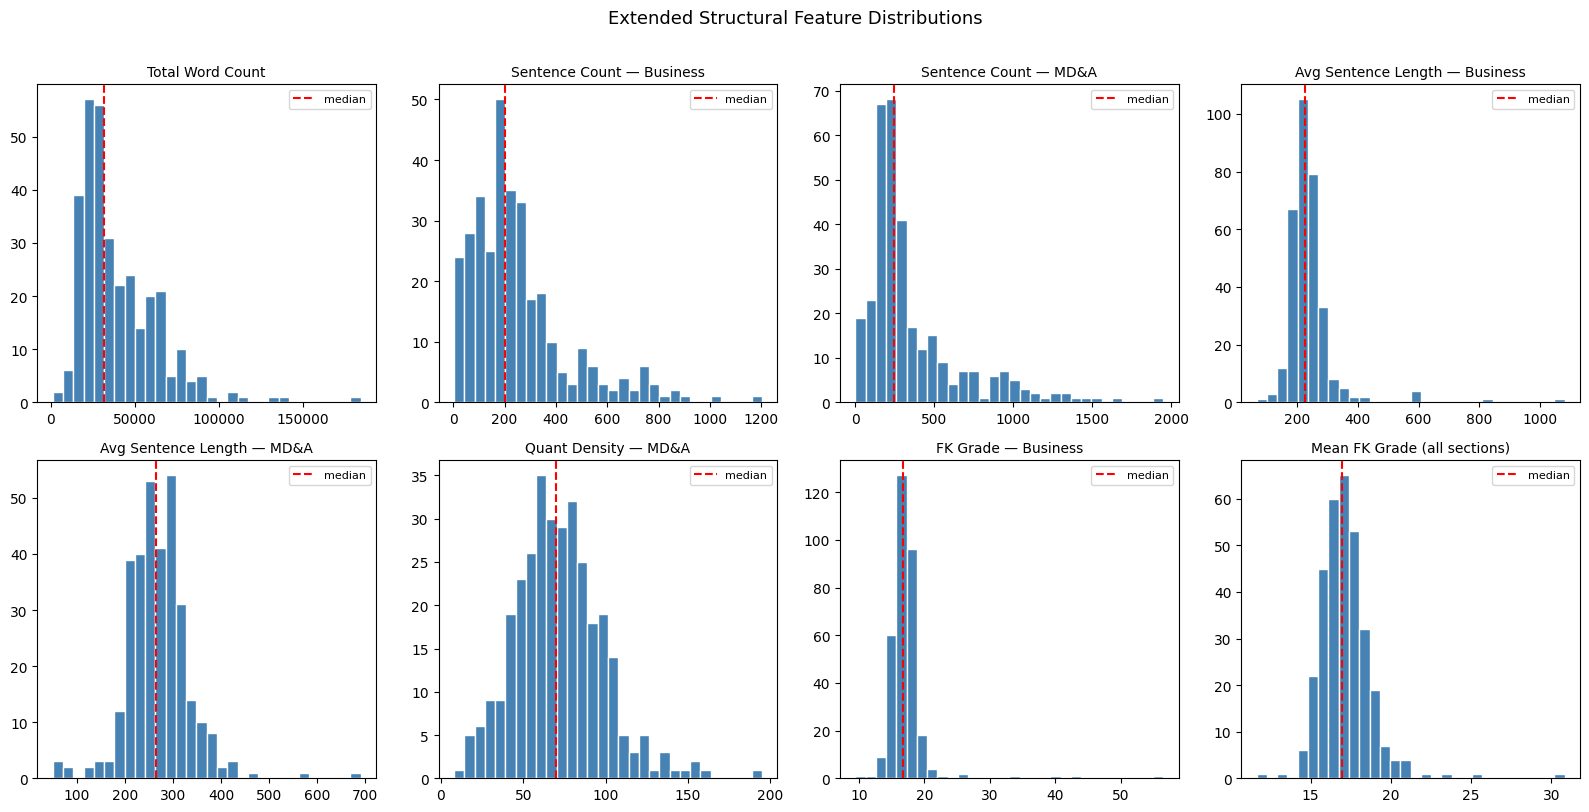

Plot saved.


In [7]:
plot_cols = [
    ("total_word_count",               "Total Word Count"),
    ("business_sentence_count_full",   "Sentence Count — Business"),
    ("mda_sentence_count_full",        "Sentence Count — MD&A"),
    ("business_avg_sentence_length",   "Avg Sentence Length — Business"),
    ("mda_avg_sentence_length",        "Avg Sentence Length — MD&A"),
    ("mda_quant_density",              "Quant Density — MD&A"),
    ("business_fk_grade",              "FK Grade — Business"),
    ("mean_fk_grade",                  "Mean FK Grade (all sections)"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (col, title) in zip(axes.flat, plot_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor="white", color="steelblue")
    ax.axvline(df[col].median(), color="red", linestyle="--", label="median")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Extended Structural Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/finbert_features/extended_structural_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved.")

## Step 7 — Correlation with ESG Targets

Merged rows: 323
Top correlations with total_score:
business_sentence_count_full        0.198198
business_word_count                 0.174321
business_is_long                    0.168024
risk_factors_sentence_count_full    0.146974
mda_is_long                         0.143549
mean_fk_grade                       0.139684
risk_factors_word_count             0.133581
mda_word_count                      0.122807
business_fk_grade                   0.117972
mda_fk_grade                        0.109053
Name: total_score, dtype: float64


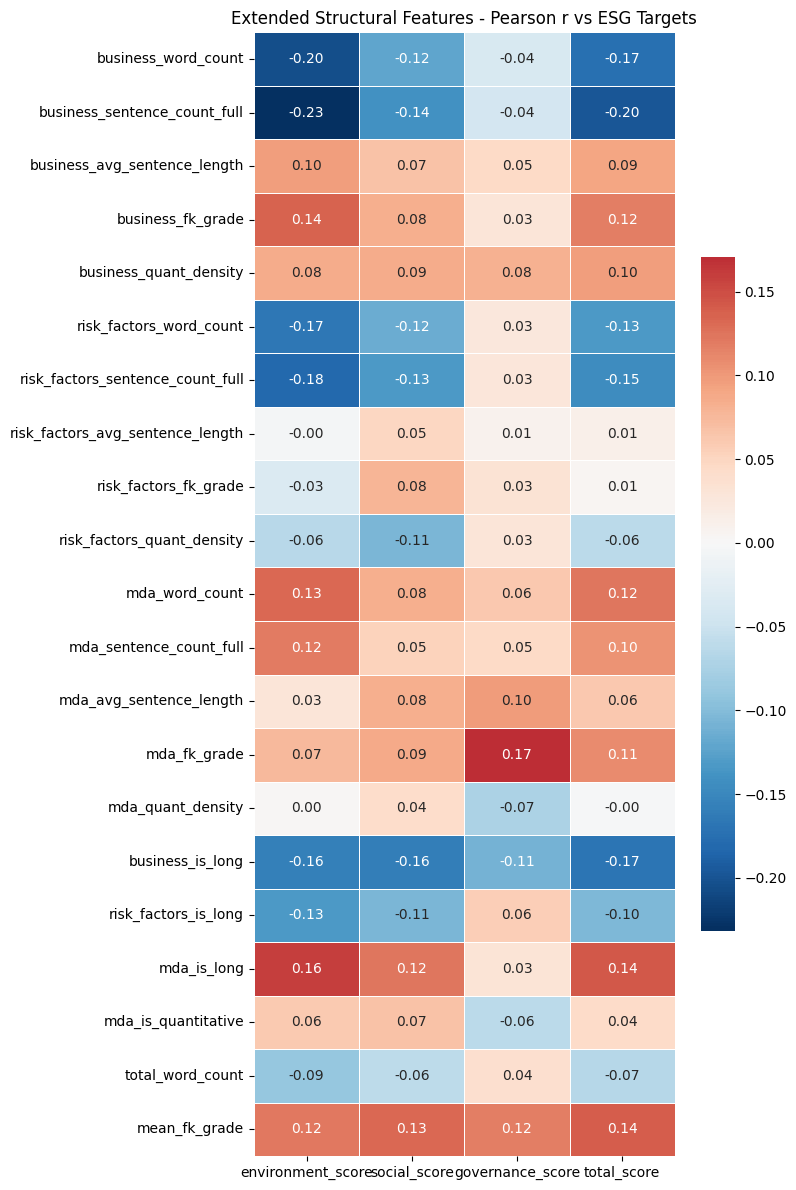

Correlation heatmap saved.


In [11]:
esg = pd.read_csv("../data/ESG_data_cleaned.csv")[["ticker", "environment_score", "social_score", "governance_score", "total_score"]]
esg["ticker"] = esg["ticker"].str.upper()
merged = df.merge(esg, on="ticker", how="inner")
print(f"Merged rows: {len(merged)}")

feat_cols = [c for c in df.columns if c != "ticker"]
targets   = ["environment_score", "social_score", "governance_score", "total_score"]

corr = merged[feat_cols + targets].corr()[targets].loc[feat_cols]
print("Top correlations with total_score:")
print(corr["total_score"].abs().sort_values(ascending=False).head(10))

plt.figure(figsize=(8, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.4, cbar_kws={"shrink": 0.6})
plt.title("Extended Structural Features - Pearson r vs ESG Targets")
plt.tight_layout()
plt.savefig("../data/finbert_features/extended_structural_corr_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Correlation heatmap saved.")

## Step 8 — Save Output

In [12]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {df.shape[0]} rows x {df.shape[1]} cols -> {OUTPUT_CSV}")
print("Feature columns:", [c for c in df.columns if c != "ticker"])

Saved: 323 rows x 22 cols -> ../data/structured_features/extended_structural_features.csv
Feature columns: ['business_word_count', 'business_sentence_count_full', 'business_avg_sentence_length', 'business_fk_grade', 'business_quant_density', 'risk_factors_word_count', 'risk_factors_sentence_count_full', 'risk_factors_avg_sentence_length', 'risk_factors_fk_grade', 'risk_factors_quant_density', 'mda_word_count', 'mda_sentence_count_full', 'mda_avg_sentence_length', 'mda_fk_grade', 'mda_quant_density', 'business_is_long', 'risk_factors_is_long', 'mda_is_long', 'mda_is_quantitative', 'total_word_count', 'mean_fk_grade']
